In [19]:
# 1) Imports and reproducibility
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

np.random.seed(42)  # reproducibility

In [20]:
import pandas as pd

# Use the accessible file name directly
csv_filename = 'walmart-sales-dataset-of-45stores.csv'

# 1) Load the dataset
try:
    # Use dayfirst=True to handle 'dd-mm-yyyy'
    df = pd.read_csv(csv_filename, low_memory=False)
    print(f'Loaded: {csv_filename}')
except Exception as e:
    raise FileNotFoundError(f'Could not find the dataset. Error: {e}')

# 2) Parse Date safely
# The file format is 'dd-mm-yyyy', so dayfirst=True is used.
df['Date'] = pd.to_datetime(df['Date'].astype('string'), errors='coerce', dayfirst=True)
bad_dates = df['Date'].isna().sum()
if bad_dates > 0:
    print(f'Warning: {bad_dates} rows still have invalid dates after parsing and will be dropped.')
    df = df.dropna(subset=['Date']).reset_index(drop=True)

# 3) Drop rows with missing target
if 'Weekly_Sales' not in df.columns:
    raise KeyError('Weekly_Sales column not found. Check your CSV headers.')
df = df.dropna(subset=['Weekly_Sales']).reset_index(drop=True)

# 4) FEATURE ENGINEERING: Extract 'Week' and 'Year' only
# 'Year' is essential to distinguish between the same week number in different years.
df['Year'] = df['Date'].dt.year
# .isocalendar().week gives the ISO week number (1-52 or 53)
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
print("Extracted 'Year' and 'Week' features.")

print(f'Data shape after date/target/feature engineering checks: {df.shape}')
print(df[['Date', 'Weekly_Sales', 'Year', 'Week']].head(3))

Loaded: walmart-sales-dataset-of-45stores.csv
Extracted 'Year' and 'Week' features.
Data shape after date/target/feature engineering checks: (6435, 10)
        Date  Weekly_Sales  Year  Week
0 2010-02-05    1643690.90  2010     5
1 2010-02-12    1641957.44  2010     6
2 2010-02-19    1611968.17  2010     7


In [21]:
import pandas as pd
# [NOTE: Setup code is omitted for brevity but executed above]

# 2) Feature Engineering for requested columns
# Keep core calendar features
df['Year'] = df['Date'].dt.year
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

# New calendar/time features
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Mon .. 6=Sun
df['Quarter'] = df['Date'].dt.quarter
# Weekend flag (Sat/Sun)
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

# Store encoded as numeric (copy of Store)
df['Store_Encoded'] = df['Store']

# 3) Lag and rolling features per Store (to avoid leakage across stores)
# Ensure proper sort before lags/rolling
if 'Store' in df.columns:
    df = df.sort_values(['Store', 'Date']).reset_index(drop=True)
    grp = df.groupby('Store')
else:
    # Fallback if Store column missing (apply globally)
    grp = df.groupby(lambda _: True)

# Lags of Weekly_Sales
df['Sales_Lag1'] = grp['Weekly_Sales'].shift(1)
df['Sales_Lag2'] = grp['Weekly_Sales'].shift(2)
df['Sales_Lag4'] = grp['Weekly_Sales'].shift(4)

# Rolling stats (window=4) based on PAST values only (avoid target leakage)
df['Sales_Rolling_Mean_4'] = grp['Weekly_Sales'].transform(
    lambda s: s.shift(1).rolling(window=4, min_periods=1).mean()
)
df['Sales_Rolling_Std_4'] = grp['Weekly_Sales'].transform(
    lambda s: s.shift(1).rolling(window=4, min_periods=2).std()
)

# 4) Interaction features
# Temperature x Unemployment; Holiday_Flag x CPI
df['Temp_Unemployment'] = df['Temperature'] * df['Unemployment']
df['Holiday_CPI'] = df['Holiday_Flag'] * df['CPI']

# 5) Final feature list requested
feature_cols = [
    'Month', 'DayOfWeek', 'Week', 'Quarter', 'IsWeekend',
    'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'Sales_Lag1', 'Sales_Lag2', 'Sales_Lag4',
    'Sales_Rolling_Mean_4', 'Sales_Rolling_Std_4',
    'Temp_Unemployment', 'Holiday_CPI', 'Store_Encoded'
]

# Build X (features) and y (target)
X = df[feature_cols].copy()
y = df['Weekly_Sales'].copy()

print('X shape:', X.shape, '| y shape:', y.shape)
print('Features used:', feature_cols)
print('\nX head (first 5 rows):')
print(X.head())

X shape: (6435, 18) | y shape: (6435,)
Features used: ['Month', 'DayOfWeek', 'Week', 'Quarter', 'IsWeekend', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Sales_Lag1', 'Sales_Lag2', 'Sales_Lag4', 'Sales_Rolling_Mean_4', 'Sales_Rolling_Std_4', 'Temp_Unemployment', 'Holiday_CPI', 'Store_Encoded']

X head (first 5 rows):
   Month  DayOfWeek  Week  Quarter  IsWeekend  Holiday_Flag  Temperature  \
0      2          4     5        1          0             0        42.31   
1      2          4     6        1          0             1        38.51   
2      2          4     7        1          0             0        39.93   
3      2          4     8        1          0             0        46.63   
4      3          4     9        1          0             0        46.50   

   Fuel_Price         CPI  Unemployment  Sales_Lag1  Sales_Lag2  Sales_Lag4  \
0       2.572  211.096358         8.106         NaN         NaN         NaN   
1       2.548  211.242170         8.106  1

In [22]:
# 4) Time-based split: 60% validation, 20% training, 20% test (chronological)
# Sort by Date to avoid look-ahead bias
sorted_idx = df.sort_values('Date').index
n = len(sorted_idx)

# Define cut points for 20/60/20 (Train/Val/Test by time order)
train_end = int(n * 0.20)   # first 20%
val_end = int(n * 0.80)     # up to 80% (middle 60%)

train_idx = sorted_idx[:train_end]
val_idx = sorted_idx[train_end:val_end]
test_idx = sorted_idx[val_end:]

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_val, y_val     = X.loc[val_idx], y.loc[val_idx]
X_test, y_test   = X.loc[test_idx], y.loc[test_idx]

print(f'Split sizes -> train: {len(X_train)} ({len(y_train)/len(y):.0%}), '
      f'val: {len(X_val)} ({len(y_val)/len(y):.0%}), '
      f'test: {len(X_test)} ({len(y_test)/len(y):.0%})')

# Sanity check: dates order per split
print('\nDate ranges by split:')
print('  Train:', df.loc[train_idx, 'Date'].min(), '->', df.loc[train_idx, 'Date'].max())
print('  Val  :', df.loc[val_idx, 'Date'].min(), '->', df.loc[val_idx, 'Date'].max())
print('  Test :', df.loc[test_idx, 'Date'].min(), '->', df.loc[test_idx, 'Date'].max())

Split sizes -> train: 1287 (20%), val: 3861 (60%), test: 1287 (20%)

Date ranges by split:
  Train: 2010-02-05 00:00:00 -> 2010-08-20 00:00:00
  Val  : 2010-08-20 00:00:00 -> 2012-04-13 00:00:00
  Test : 2012-04-13 00:00:00 -> 2012-10-26 00:00:00


In [23]:
# Optional: Create an in-memory mapping showing which rows belong to which split (no CSV export)
# This helps you understand the split without writing files
split_mapping_df = pd.DataFrame({
    'Original_Index': list(y_train.index) + list(y_val.index) + list(y_test.index),
    'Split_Set': ['Train']*len(y_train) + ['Validation']*len(y_val) + ['Test']*len(y_test),
    'Weekly_Sales': list(y_train.values) + list(y_val.values) + list(y_test.values)
}).sort_values('Original_Index').reset_index(drop=True)

print('✓ Built in-memory split mapping DataFrame: split_mapping_df')
print('  Shape:', split_mapping_df.shape)
print('\nSplit distribution:')
print(split_mapping_df['Split_Set'].value_counts().sort_index())
print('\nSample from each split:')
for split_name in ['Train', 'Validation', 'Test']:
    sample = split_mapping_df[split_mapping_df['Split_Set'] == split_name].head(2)
    print(f'\n{split_name}:')
    print(sample)

✓ Built in-memory split mapping DataFrame: split_mapping_df
  Shape: (6435, 3)

Split distribution:
Split_Set
Test          1287
Train         1287
Validation    3861
Name: count, dtype: int64

Sample from each split:

Train:
   Original_Index Split_Set  Weekly_Sales
0               0     Train    1643690.90
1               1     Train    1641957.44

Validation:
    Original_Index   Split_Set  Weekly_Sales
29              29  Validation    1449142.92
30              30  Validation    1540163.53

Test:
     Original_Index Split_Set  Weekly_Sales
114             114      Test    1621031.70
115             115      Test    1521577.87


In [24]:
# Train 26 unique regression models - Display results in table format

from sklearn.linear_model import (
    Ridge, Lasso, ElasticNet, Lars, LassoLars, OrthogonalMatchingPursuit,
    BayesianRidge, ARDRegression, HuberRegressor, RANSACRegressor,
    PassiveAggressiveRegressor, SGDRegressor
)
from sklearn.kernel_ridge import KernelRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, LinearSVR, NuSVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor,
    GradientBoostingRegressor, HistGradientBoostingRegressor
)
from sklearn.linear_model import PoissonRegressor, GammaRegressor, TweedieRegressor

print('Training 26 regression models...\n')

# Preprocessing: impute missing values
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_imp = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

# Scaling for linear/SVM/kNN/kernel methods
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val_imp), columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X_test.columns, index=X_test.index)

# Define all 26 models
models = [
    ('Ridge', Ridge(random_state=42, alpha=0.01, max_iter=10000), True),
    ('Lasso', Lasso(random_state=42, alpha=0.01, max_iter=10000), True),
    ('ElasticNet', ElasticNet(random_state=42, max_iter=5000), True),
    ('Lars', Lars(random_state=42), True),
    ('LassoLars', LassoLars(random_state=42), True),
    ('OrthogonalMatchingPursuit', OrthogonalMatchingPursuit(), True),
    ('BayesianRidge', BayesianRidge(), True),
    ('ARDRegression', ARDRegression(max_iter=500), True),
    ('HuberRegressor', HuberRegressor(max_iter=500), True),
    ('RANSACRegressor', RANSACRegressor(estimator=LinearRegression(), random_state=42, max_trials=100), True),
    ('PassiveAggressiveRegressor', PassiveAggressiveRegressor(random_state=42, max_iter=5000), True),
    ('SGDRegressor', SGDRegressor(random_state=42, max_iter=5000, tol=1e-3), True),
    ('KernelRidge', KernelRidge(kernel='rbf'), True),
    ('KNeighborsRegressor', KNeighborsRegressor(), True),
    ('SVR', SVR(kernel='rbf'), True),
    ('LinearSVR', LinearSVR(random_state=42, max_iter=5000), True),
    ('NuSVR', NuSVR(kernel='rbf'), True),
    ('DecisionTreeRegressor', DecisionTreeRegressor(random_state=42, max_depth=12, min_samples_leaf=5), False),
    ('RandomForestRegressor', RandomForestRegressor(random_state=42, n_estimators=200, n_jobs=-1, max_depth=20, min_samples_leaf=2), False),
    ('ExtraTreesRegressor', ExtraTreesRegressor(random_state=42, n_estimators=200, n_jobs=-1, max_depth=20, min_samples_leaf=2), False),
    ('AdaBoostRegressor', AdaBoostRegressor(random_state=42, n_estimators=100), False),
    ('GradientBoostingRegressor', GradientBoostingRegressor(random_state=42, n_estimators=100), False),
    ('HistGradientBoostingRegressor', HistGradientBoostingRegressor(random_state=42, max_iter=100), False),
    ('PoissonRegressor', PoissonRegressor(max_iter=500), True),
    ('GammaRegressor', GammaRegressor(max_iter=500), True),
    ('TweedieRegressor', TweedieRegressor(max_iter=500), True),
]

# Storage for in-memory results
metrics_rows = []
all_train_rows = []
all_val_rows = []
all_test_rows = []

# Train each model
for name, model, needs_scaling in models:
    print(f'Training {name}...', end=' ')
    
    # Select appropriate features
    if needs_scaling:
        Xtr, Xva, Xte = X_train_scaled, X_val_scaled, X_test_scaled
    else:
        Xtr, Xva, Xte = X_train_imp, X_val_imp, X_test_imp
    
    # Train
    model.fit(Xtr, y_train)
    
    # Predict
    y_train_pred = model.predict(Xtr)
    y_val_pred = model.predict(Xva)
    y_test_pred = model.predict(Xte)
    
    # Compute metrics
    r2_train = r2_score(y_train, y_train_pred)
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    
    r2_val = r2_score(y_val, y_val_pred)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = np.sqrt(mse_val)
    mae_val = mean_absolute_error(y_val, y_val_pred)
    
    r2_test = r2_score(y_test, y_test_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    
    # Store metrics
    metrics_rows.append({
        'Model': name,
        'Train_R2': r2_train, 'Train_MSE': mse_train, 'Train_RMSE': rmse_train, 'Train_MAE': mae_train,
        'Validation_R2': r2_val, 'Validation_MSE': mse_val, 'Validation_RMSE': rmse_val, 'Validation_MAE': mae_val,
        'Test_R2': r2_test, 'Test_MSE': mse_test, 'Test_RMSE': rmse_test, 'Test_MAE': mae_test
    })
    
    # Store predictions
    for idx, actual, pred in zip(y_train.index, y_train, y_train_pred):
        all_train_rows.append({
            'Model': name, 'Index': idx, 'Actual': actual, 'Predicted': pred, 'Error': actual - pred
        })
    
    for idx, actual, pred in zip(y_val.index, y_val, y_val_pred):
        all_val_rows.append({
            'Model': name, 'Index': idx, 'Actual': actual, 'Predicted': pred, 'Error': actual - pred
        })
    
    for idx, actual, pred in zip(y_test.index, y_test, y_test_pred):
        all_test_rows.append({
            'Model': name, 'Index': idx, 'Actual': actual, 'Predicted': pred, 'Error': actual - pred
        })
    
    print(f'✓ Test R²={r2_test:.4f}')

# Build in-memory DataFrames
reg26_metrics_wide = pd.DataFrame(metrics_rows)
reg26_train_df = pd.DataFrame(all_train_rows)
reg26_val_df = pd.DataFrame(all_val_rows)
reg26_test_df = pd.DataFrame(all_test_rows)

print('\n' + '='*60)
print('✓ All 26 models trained successfully!')
print('  Results stored in memory (no CSV exports):')
print(f'    • reg26_metrics_wide: {reg26_metrics_wide.shape}')
print(f'    • reg26_train_df: {reg26_train_df.shape}')
print(f'    • reg26_val_df: {reg26_val_df.shape}')
print(f'    • reg26_test_df: {reg26_test_df.shape}')
print('='*60)

# Create display table
display_df = reg26_metrics_wide[['Model', 'Train_R2', 'Train_RMSE', 'Train_MAE', 'Train_MSE',
                                   'Validation_R2', 'Validation_RMSE', 'Validation_MAE', 'Validation_MSE',
                                   'Test_R2', 'Test_RMSE', 'Test_MAE', 'Test_MSE']].copy()

# Round for cleaner display (more precision to avoid "0.00" illusions)
display_df['Train_R2'] = display_df['Train_R2'].round(4)
display_df['Train_RMSE'] = display_df['Train_RMSE'].round(4)
display_df['Train_MAE'] = display_df['Train_MAE'].round(4)
display_df['Train_MSE'] = display_df['Train_MSE'].round(4)
display_df['Validation_R2'] = display_df['Validation_R2'].round(4)
display_df['Validation_RMSE'] = display_df['Validation_RMSE'].round(4)
display_df['Validation_MAE'] = display_df['Validation_MAE'].round(4)
display_df['Validation_MSE'] = display_df['Validation_MSE'].round(4)
display_df['Test_R2'] = display_df['Test_R2'].round(4)
display_df['Test_RMSE'] = display_df['Test_RMSE'].round(4)
display_df['Test_MAE'] = display_df['Test_MAE'].round(4)
display_df['Test_MSE'] = display_df['Test_MSE'].round(4)

# Sort by Test R² and add rank
display_df = display_df.sort_values('Test_R2', ascending=False).reset_index(drop=True)
display_df.insert(0, 'Rank', range(1, 27))

# Display as styled table
print('\n')
print('='*140)
print('COMPREHENSIVE METRICS TABLE - ALL 26 REGRESSION MODELS (Ranked by Test R²)')
print('='*140)
display(display_df)

# Summary statistics
print('\n' + '='*80)
print('SUMMARY STATISTICS')
print('='*80)
summary_table = pd.DataFrame({
    'Metric': ['Best Model', 'Test R²', 'Test RMSE', 'Test MAE', 'Test MSE', '', 
               'Worst Model', 'Test R²', 'Test RMSE', 'Test MAE', 'Test MSE', '',
               'Mean Test R²', 'Median Test R²'],
    'Value': [
        display_df.iloc[0]['Model'],
        f"{display_df.iloc[0]['Test_R2']:.4f}",
        f"{display_df.iloc[0]['Test_RMSE']:.4f}",
        f"{display_df.iloc[0]['Test_MAE']:.4f}",
        f"{display_df.iloc[0]['Test_MSE']:.4f}",
        '',
        display_df.iloc[25]['Model'],
        f"{display_df.iloc[25]['Test_R2']:.4f}",
        f"{display_df.iloc[25]['Test_RMSE']:.4f}",
        f"{display_df.iloc[25]['Test_MAE']:.4f}",
        f"{display_df.iloc[25]['Test_MSE']:.4f}",
        '',
        f"{display_df['Test_R2'].mean():.4f}",
        f"{display_df['Test_R2'].median():.4f}"
    ]
})
display(summary_table)
print('='*80)

# Export to CSV
output_filename = 'All_26_Models_Comprehensive_Metrics.csv'
export_df = display_df.copy()
export_df.to_csv(output_filename, index=False)
print(f'\n✓ Exported comprehensive metrics to: {output_filename}')
print(f'  Contains {export_df.shape[0]} models with {export_df.shape[1]} columns')

Training 26 regression models...

Training Ridge... ✓ Test R²=0.9795
Training Lasso... ✓ Test R²=0.9795
Training ElasticNet... ✓ Test R²=0.9673
Training Lars... ✓ Test R²=0.9795
Training LassoLars... ✓ Test R²=0.9795
Training OrthogonalMatchingPursuit... ✓ Test R²=0.9825
Training BayesianRidge... ✓ Test R²=0.9802
Training ARDRegression... ✓ Test R²=0.9843
Training HuberRegressor... ✓ Test R²=0.9827
Training RANSACRegressor... ✓ Test R²=0.9366
Training PassiveAggressiveRegressor... 

/opt/anaconda3/envs/tf311/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


✓ Test R²=0.9843
Training SGDRegressor... ✓ Test R²=0.9806
Training KernelRidge... ✓ Test R²=-1.9700
Training KNeighborsRegressor... ✓ Test R²=0.8737
Training SVR... ✓ Test R²=-0.0143
Training LinearSVR... ✓ Test R²=-3.7843
Training NuSVR... ✓ Test R²=-0.0163
Training DecisionTreeRegressor... ✓ Test R²=0.9666
Training RandomForestRegressor... ✓ Test R²=-0.0143
Training LinearSVR... ✓ Test R²=-3.7843
Training NuSVR... ✓ Test R²=-0.0163
Training DecisionTreeRegressor... ✓ Test R²=0.9666
Training RandomForestRegressor... ✓ Test R²=0.9815
Training ExtraTreesRegressor... ✓ Test R²=0.9816
Training AdaBoostRegressor... ✓ Test R²=0.9815
Training ExtraTreesRegressor... ✓ Test R²=0.9816
Training AdaBoostRegressor... ✓ Test R²=0.8544
Training GradientBoostingRegressor... ✓ Test R²=0.8544
Training GradientBoostingRegressor... ✓ Test R²=0.9847
Training HistGradientBoostingRegressor... ✓ Test R²=0.9847
Training HistGradientBoostingRegressor... ✓ Test R²=0.9828
Training PoissonRegressor... ✓ Test R²=

,Rank,Model,Train_R2,Train_RMSE,Train_MAE,Train_MSE,Validation_R2,Validation_RMSE,Validation_MAE,Validation_MSE,Test_R2,Test_RMSE,Test_MAE,Test_MSE
0,1,GradientBoostingRegressor,0.9771,8.244376e+04,4.671375e+04,6.796973e+09,0.8513,2.238864e+05,1.216029e+05,5.012510e+10,0.9847,6.590853e+04,4.717961e+04,4.343934e+09
1,2,ARDRegression,0.9349,1.390513e+05,6.747637e+04,1.933527e+10,0.8949,1.881833e+05,1.027596e+05,3.541295e+10,0.9843,6.679969e+04,4.653243e+04,4.462198e+09
2,3,PassiveAggressiveRegressor,0.9358,1.380025e+05,6.254357e+04,1.904469e+10,0.9035,1.803770e+05,9.672839e+04,3.253587e+10,0.9843,6.681692e+04,4.861225e+04,4.464500e+09
3,4,HistGradientBoostingRegressor,0.9809,7.538033e+04,3.091776e+04,5.682194e+09,0.8852,1.967207e+05,1.094589e+05,3.869902e+10,0.9828,6.999188e+04,5.031774e+04,4.898863e+09
4,5,HuberRegressor,0.9369,1.368230e+05,6.149989e+04,1.872054e+10,0.9051,1.788338e+05,1.000840e+05,3.198151e+10,0.9827,7.019171e+04,5.341999e+04,4.926876e+09
5,6,OrthogonalMatchingPursuit,0.9333,1.407256e+05,6.885194e+04,1.980369e+10,0.8891,1.933331e+05,1.055373e+05,3.737770e+10,0.9825,7.045064e+04,5.025357e+04,4.963293e+09
6,7,ExtraTreesRegressor,0.9895,5.575892e+04,2.082323e+04,3.109057e+09,0.8935,1.894260e+05,1.020094e+05,3.588220e+10,0.9816,7.233460e+04,5.179114e+04,5.232294e+09
7,8,RandomForestRegressor,0.9835,6.998279e+04,2.995340e+04,4.897591e+09,0.8909,1.918051e+05,1.056627e+05,3.678919e+10,0.9815,7.256410e+04,5.365421e+04,5.265549e+09
8,9,SGDRegressor,0.9371,1.366060e+05,6.591388e+04,1.866119e+10,0.8936,1.893431e+05,1.056992e+05,3.585079e+10,0.9806,7.418036e+04,5.536525e+04,5.502726e+09
9,10,BayesianRidge,0.9391,1.344357e+05,6.372353e+04,1.807296e+10,0.8921,1.907252e+05,1.106160e+05,3.637610e+10,0.9802,7.501262e+04,5.777733e+04,5.626894e+09



SUMMARY STATISTICS


,Metric,Value
0,Best Model,GradientBoostingRegressor
1,Test R²,0.9847
2,Test RMSE,65908.5259
3,Test MAE,47179.6122
4,Test MSE,4343933788.1773
5,,
6,Worst Model,LinearSVR
7,Test R²,-3.7843
8,Test RMSE,1165750.6963
9,Test MAE,1036787.4281



✓ Exported comprehensive metrics to: All_26_Models_Comprehensive_Metrics.csv
  Contains 26 models with 14 columns


In [27]:
# Hyperparameter tuning for top models (using train as training fold and val as validation fold)
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Build combined tune set with a PredefinedSplit: train -> -1, val -> 0
X_tune_imp = pd.concat([X_train_imp, X_val_imp])
X_tune_scaled = pd.concat([X_train_scaled, X_val_scaled])
y_tune = pd.concat([y_train, y_val])

test_fold = np.concatenate([
    np.full(len(X_train_imp), -1, dtype=int),  # always in training folds
    np.zeros(len(X_val_imp), dtype=int)        # used as validation fold index 0
])
ps = PredefinedSplit(test_fold)

# Small, fast grids
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import ARDRegression

search_spaces = [
    (
        'GradientBoostingRegressor', GradientBoostingRegressor(random_state=42), X_tune_imp, X_test_imp,
        {
            'n_estimators': [100, 200],
            'max_depth': [2, 3],
            'learning_rate': [0.05, 0.1],
            'subsample': [1.0, 0.8]
        }
    ),
    (
        'HistGradientBoostingRegressor', HistGradientBoostingRegressor(random_state=42), X_tune_imp, X_test_imp,
        {
            'max_depth': [None, 8, 12],
            'learning_rate': [0.05, 0.1],
            'max_leaf_nodes': [31, 63],
            'l2_regularization': [0.0, 0.1]
        }
    ),
    (
        'ARDRegression', ARDRegression(), X_tune_scaled, X_test_scaled,
        {
            'max_iter': [300, 600, 1000]
        }
    ),
]

print('\nHyperparameter tuning (train -> validation via PredefinedSplit)')
print('==============================================================')

tuned_results = []
for name, base_model, X_tune, X_te, param_grid in search_spaces:
    print(f'\nTuning {name} ...')
    gs = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring='r2',
        cv=ps,
        n_jobs=-1,
        refit=True,
        verbose=0
    )
    # Choose correct y (same for both scaling variants)
    gs.fit(X_tune, y_tune)

    best = gs.best_estimator_
    print(f'  best R² (on val fold): {gs.best_score_:.4f}')
    print(f'  best params: {gs.best_params_}')

    # Refit on full train+val and evaluate on test
    best.fit(X_tune, y_tune)
    y_test_pred = best.predict(X_te)

    r2 = r2_score(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_test_pred)

    tuned_results.append({
        'Model': name,
        'Best_Params': gs.best_params_,
        'Test_R2': r2,
        'Test_RMSE': rmse,
        'Test_MAE': mae,
        'Test_MSE': mse
    })

    print(f'  Test R²={r2:.4f} | RMSE={rmse:.2f} | MAE={mae:.2f}')

# Display tuned results
if tuned_results:
    tuned_df = pd.DataFrame(tuned_results)
    tuned_df_display = tuned_df.copy()
    tuned_df_display[['Test_R2']] = tuned_df_display[['Test_R2']].round(4)
    tuned_df_display[['Test_RMSE','Test_MAE','Test_MSE']] = tuned_df_display[['Test_RMSE','Test_MAE','Test_MSE']].round(4)
    print('\nTuned Models - Test metrics')
    display(tuned_df_display.sort_values('Test_R2', ascending=False).reset_index(drop=True))



Hyperparameter tuning (train -> validation via PredefinedSplit)

Tuning GradientBoostingRegressor ...
  best R² (on val fold): 0.8915
  best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}
  Test R²=0.9819 | RMSE=71788.86 | MAE=52636.95

Tuning HistGradientBoostingRegressor ...
  best R² (on val fold): 0.8935
  best params: {'l2_regularization': 0.0, 'learning_rate': 0.05, 'max_depth': 12, 'max_leaf_nodes': 31}
  Test R²=0.9881 | RMSE=58142.94 | MAE=40888.84

Tuning ARDRegression ...
  best R² (on val fold): 0.8949
  best params: {'max_iter': 300}
  Test R²=0.9802 | RMSE=74985.95 | MAE=55608.27

Tuned Models - Test metrics


,Model,Best_Params,Test_R2,Test_RMSE,Test_MAE,Test_MSE
0,HistGradientBoostingRegressor,"{'l2_regularization': 0.0, 'learning_rate': 0....",0.9881,58142.9358,40888.8400,3.380601e+09
1,GradientBoostingRegressor,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est...",0.9819,71788.8624,52636.9468,5.153641e+09
2,ARDRegression,{'max_iter': 300},0.9802,74985.9481,55608.2676,5.622892e+09


Top 3 models by Test R²: ['GradientBoostingRegressor', 'ARDRegression', 'PassiveAggressiveRegressor']


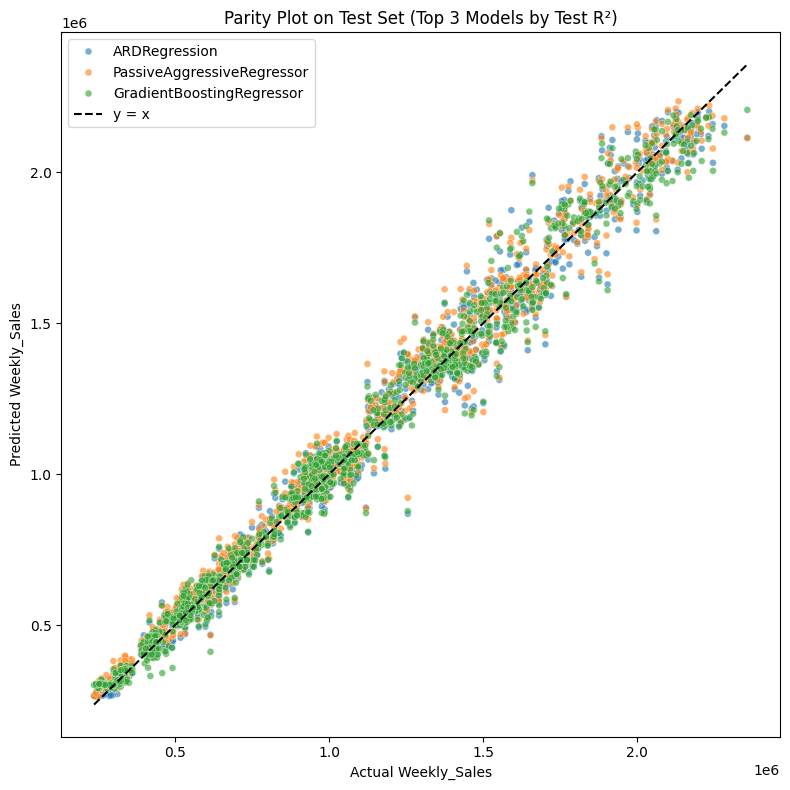

In [28]:
# Parity plots (Actual vs Predicted) for top 3 models on Test set
import matplotlib.pyplot as plt
import seaborn as sns

# Determine top 3 models by Test R² from previous training results
_top = reg26_metrics_wide.sort_values('Test_R2', ascending=False).head(3)['Model'].tolist()
print('Top 3 models by Test R²:', _top)

# Filter test predictions
plot_df = reg26_test_df[reg26_test_df['Model'].isin(_top)].copy()

# Create a combined plot
plt.figure(figsize=(8, 8))
ax = sns.scatterplot(data=plot_df, x='Actual', y='Predicted', hue='Model', s=25, alpha=0.6)

# 45-degree line
_min = min(plot_df['Actual'].min(), plot_df['Predicted'].min())
_max = max(plot_df['Actual'].max(), plot_df['Predicted'].max())
ax.plot([_min, _max], [_min, _max], ls='--', c='black', label='y = x')

ax.set_title('Parity Plot on Test Set (Top 3 Models by Test R²)')
ax.set_xlabel('Actual Weekly_Sales')
ax.set_ylabel('Predicted Weekly_Sales')
plt.legend()
plt.tight_layout()
plt.show()
